# AeroNet Lite - Demand Forecasting

Module 5 notebook: forecast hourly delivery demand.

Tries to load the Kaggle Bike Sharing Demand CSV from `../data/raw/bike_sharing/train.csv`. If the file is missing, falls back to the in-process synthetic generator from `src.ml_pipeline` so the notebook still runs end-to-end without any downloads.

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make the project root importable so `from src.ml_pipeline import ...` works.
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.ml_pipeline import (
    DEMAND_FEATURES,
    generate_synthetic_demand,
    _load_bike_sharing,
)

## 1. Load data

Detects the real CSV; falls back to synthetic if absent.

In [2]:
CSV_PATH = os.path.join(PROJECT_ROOT, "data", "raw", "bike_sharing", "train.csv")

if os.path.isfile(CSV_PATH):
    df = _load_bike_sharing(CSV_PATH)
    print(f"Loaded real Bike Sharing CSV: {CSV_PATH}")
else:
    df = generate_synthetic_demand()
    print("CSV not found - using synthetic demand data.")

print(f"Shape: {df.shape}")
df.head()

Loaded real Bike Sharing CSV: d:\codes\ai2\data\raw\bike_sharing\train.csv
Shape: (10886, 5)


,hour,day_of_week,temperature,weather,count
0,0,5,9.84,1,16.0
1,1,5,9.02,1,40.0
2,2,5,9.02,1,32.0
3,3,5,9.84,1,13.0
4,4,5,9.84,1,1.0


## 2. Exploratory data analysis

In [3]:
df.describe()

,hour,day_of_week,temperature,weather,count
count,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000
mean,11.541613,3.013963,20.23086,1.418427,191.574132
std,6.915838,2.004585,7.79159,0.633839,181.144454
min,0.000000,0.000000,0.82000,1.000000,1.000000
25%,6.000000,1.000000,13.94000,1.000000,42.000000
50%,12.000000,3.000000,20.50000,1.000000,145.000000
75%,18.000000,5.000000,26.24000,2.000000,284.000000
max,23.000000,6.000000,41.00000,4.000000,977.000000


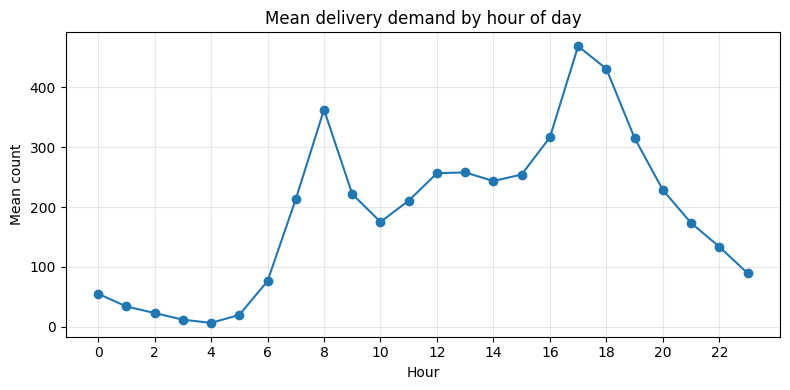

In [4]:
by_hour = df.groupby("hour")["count"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(by_hour.index, by_hour.values, marker="o")
ax.set_title("Mean delivery demand by hour of day")
ax.set_xlabel("Hour")
ax.set_ylabel("Mean count")
ax.set_xticks(range(0, 24, 2))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Train/test split

In [5]:
from sklearn.model_selection import train_test_split

X = df[DEMAND_FEATURES]
y = df["count"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train rows: {len(X_train)}  Test rows: {len(X_test)}")

Train rows: 8708  Test rows: 2178


## 4. Linear Regression vs Random Forest

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

rf = RandomForestRegressor(n_estimators=120, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print(f"LinearRegression  MAE={lr_mae:.3f}  RMSE={lr_rmse:.3f}")
print(f"RandomForest      MAE={rf_mae:.3f}  RMSE={rf_rmse:.3f}")

winner = "RandomForest" if rf_rmse <= lr_rmse else "LinearRegression"
print(f"Lower-RMSE model: {winner}")

LinearRegression  MAE=112.155  RMSE=152.776
RandomForest      MAE=56.552  RMSE=86.654
Lower-RMSE model: RandomForest


## 5. Random Forest feature importance

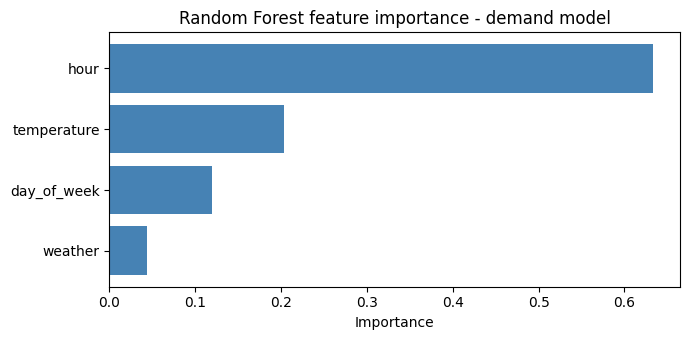

hour           0.633118
temperature    0.203895
day_of_week    0.119090
weather        0.043897
dtype: float64

In [7]:
importances = pd.Series(rf.feature_importances_, index=DEMAND_FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(importances.index, importances.values, color="steelblue")
ax.set_title("Random Forest feature importance - demand model")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

importances.sort_values(ascending=False)